In [1]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, f_oneway

In [2]:
df = pd.read_csv(
    r"C:\Users\SVS\Desktop\Product_Adoption_customer_sucess\data\processed\product_operations_processed.csv")
df.head()

,record_id,customer_id,subscription_id,subscription_plan,plan_category,subscription_start_date,subscription_end_date,billing_cycle,subscription_fee,discount_percent,...,monthly_active_user,weekly_active_user,start_year,start_month,start_day,start_quarter,end_year,end_month,end_day,end_quarter
0,REC000001,CUST000001,SUB000001,Growth,Standard,2023-05-18,2023-06-17,Monthly,299,0,...,No,No,2023,5,18,2,2023,6,17,2
1,REC000002,CUST000002,SUB000002,Growth,Standard,2024-03-04,2024-04-03,Quarterly,299,15,...,No,Yes,2024,3,4,1,2024,4,3,2
2,REC000003,CUST000003,SUB000003,Growth,Standard,2023-10-28,2023-11-27,Quarterly,299,5,...,Yes,No,2023,10,28,4,2023,11,27,4
3,REC000004,CUST000004,SUB000004,Growth,Standard,2023-02-12,2023-05-13,Quarterly,299,0,...,No,Yes,2023,2,12,1,2023,5,13,2
4,REC000005,CUST000005,SUB000005,Growth,Standard,2024-02-15,2025-02-14,Quarterly,299,5,...,Yes,Yes,2024,2,15,1,2025,2,14,1


## Correlation Matrix

In [3]:
corr = df[
    [
        "discount_percent",
        "tax_amount",
        "final_amount_paid"
    ]
].corr()
corr

,discount_percent,tax_amount,final_amount_paid
discount_percent,1.000000,-0.06724,-0.067249
tax_amount,-0.067240,1.00000,1.000000
final_amount_paid,-0.067249,1.00000,1.000000


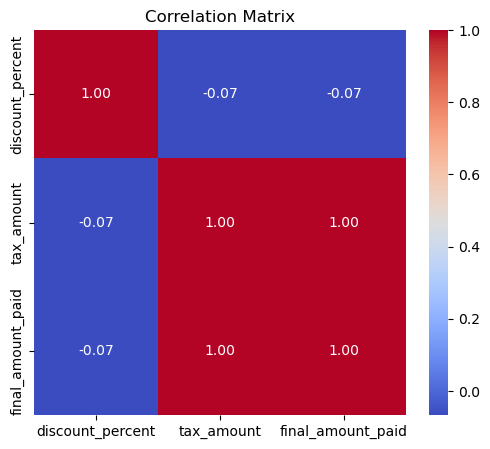

In [4]:
plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

### Correlation Interpretation

In [5]:
print(corr)

                   discount_percent  tax_amount  final_amount_paid
discount_percent           1.000000    -0.06724          -0.067249
tax_amount                -0.067240     1.00000           1.000000
final_amount_paid         -0.067249     1.00000           1.000000


## Variance Analysis

In [6]:
d## By  Plan Category
    f.groupby("plan_category")[
    [
        "discount_percent",
        "tax_amount",
        "final_amount_paid"
    ]
].agg(["mean","var"])

discount_percent             tax_amount                \
                          mean        var        mean           var   
plan_category                                                         
Premium               9.875000  49.965621  232.827812  18141.764208   
Standard              9.909167  49.533377   43.088118    158.545744   

              final_amount_paid                 
                           mean            var  
plan_category                                   
Premium             1526.304688  779649.515477  
Standard             282.455543    6813.904010

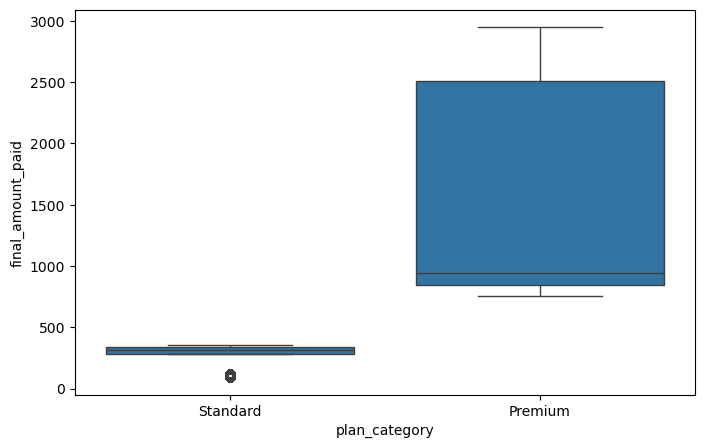

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="plan_category",
    y="final_amount_paid"
)

plt.show()

In [8]:
## By Payment Status 
df.groupby("payment_status")[
    [
        "discount_percent",
        "tax_amount",
        "final_amount_paid"
    ]
].agg(["mean","var"])

discount_percent             tax_amount                \
                           mean        var        mean           var   
payment_status                                                         
Failed                 9.654762  50.417519  123.047167  16554.476905   
Paid                   9.905282  49.651138  118.746168  15973.190623   
Pending                9.849877  50.146058  120.553854  16066.671151   

               final_amount_paid                 
                            mean            var  
payment_status                                   
Failed                806.631810  711434.608332  
Paid                  778.436094  686453.630421  
Pending               790.286544  690471.465990

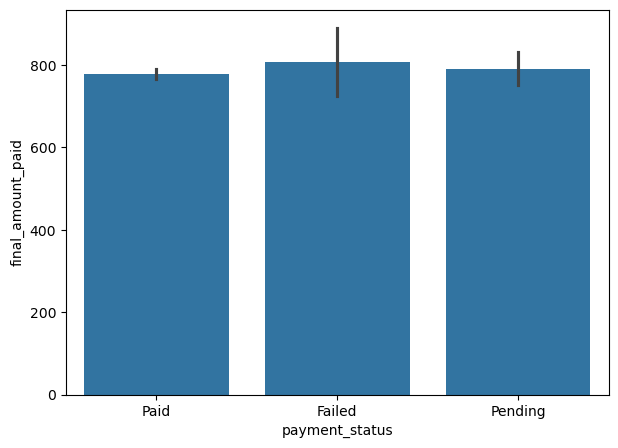

In [9]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df,
    x="payment_status",
    y="final_amount_paid"
)

plt.show()

In [10]:
## By Subscription Status 
df.groupby("subscription_status")[
    [
        "discount_percent",
        "tax_amount",
        "final_amount_paid"
    ]
].agg(["mean","var"])

discount_percent             tax_amount                \
                                mean        var        mean           var   
subscription_status                                                         
Active                        9.8955  49.704065  118.983996  15991.994084   

                    final_amount_paid                
                                 mean           var  
subscription_status                                  
Active                     779.995201  687261.75494

## Statistical Validation 

## Hypothesis

**Null Hypothesis (H₀):** There is no significant difference in the final amount paid across different plan categories.

**Alternative Hypothesis (H₁):** There is a significant difference in the final amount paid across different plan categories.

In [12]:
groups = [
    group["final_amount_paid"].values
    for _, group in df.groupby("plan_category")
]

f_stat, p_value = f_oneway(*groups)
print("F Statistic:", round(f_stat,3))
print("P-value:", p_value)

F Statistic: 23505.607
P-value: 0.0


In [13]:
alpha = 0.05
if p_value < alpha:
    print("Reject Null Hypothesis")
    print("There is a significant difference among plan categories.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference found.")

Reject Null Hypothesis
There is a significant difference among plan categories.


# Business Interpretation

- Correlation analysis shows the relationship between financial variables.
- Variance analysis compares financial metrics across different business categories.
- The statistical test validates whether the observed differences are statistically significant.

# Limitations

- The analysis is based on a single processed dataset.
- Results may not represent the entire customer population.
- Correlation does not imply causation.
- Additional datasets are required to validate business decisions.

In [14]:
df.to_csv(
    r"C:\Users\SVS\Desktop\Product_Adoption_customer_sucess\data\processed\product_operations_processed.csv", index=False)
print("Dataset saved successfully.")

Dataset saved successfully.
